In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, roc_curve, roc_auc_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
import os

In [2]:
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Rename columns to remove spaces
df = df.rename(columns={'Ward ID': 'Ward_ID'})

# Create lag features
def create_lag_features(df, lag_periods=[1, 2, 3]):
    """
    Create lag features for crime density
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time series data
    lag_periods : list
        List of lag periods to create
    Returns:
    --------
    pandas DataFrame with added lag features
    """
    # Sort the dataframe by Ward_ID, Year, and Month_Num
    df = df.sort_values(['Ward_ID', 'Year', 'Month_Num'])
    
    # Create lag features for each ward separately
    for ward in df['Ward_ID'].unique():
        ward_mask = df['Ward_ID'] == ward
        for lag in lag_periods:
            df.loc[ward_mask, f'Crime_Density_Lag_{lag}'] = df.loc[ward_mask, 'Monthly_Crime_Density'].shift(lag)# for each lag period, shifting the crime density values by that many periods.
    
    return df

# Create lag features
df_with_lags = create_lag_features(df)

# Encode Ward_ID
le = LabelEncoder()
df_with_lags['Ward_ID_Encoded'] = le.fit_transform(df_with_lags['Ward_ID'])

# Binning target variable into 3 categories (low, mid, high crime density)
df_with_lags['Crime_Density_Level'] = pd.qcut(df_with_lags['Monthly_Crime_Density'], q=3, labels=[0, 1, 2])

# Defining the features
lag_features = [f'Crime_Density_Lag_{lag}' for lag in [1, 2, 3]]
features = ['Ward_ID_Encoded', 'Year', 'Month_Num'] + lag_features
target = 'Crime_Density_Level'

# Train-test split
df_train = df_with_lags[df_with_lags['Year'] <= 2024]
df_test = df_with_lags[df_with_lags['Year'] > 2024]

# Drop rows with NaN values in any of the features
df_train = df_train.dropna(subset=features + [target])
df_test = df_test.dropna(subset=features + [target])

X_train = df_train[features]
y_train = df_train[target].astype(int)
X_test = df_test[features]
y_test = df_test[target].astype(int)

## Load the decision tree class

We let the model fit with its training data.

In [3]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_split=13, random_state=42, criterion="entropy")
dt_default = DecisionTreeClassifier(random_state=42)

## Train and evaluate, the class loads data from CSV, trains, evaluates

In [4]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dt.fit(X_train_scaled, y_train)

# text
y_pred = dt.predict(X_test_scaled)
y_pred_prob = dt.predict_proba(X_test_scaled)  # Keep full matrix


# Binarize the output labels for multiclass AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Compute AUC using OvR strategy
auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("ROC AUC Score:", auc)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.6290189612530915
ROC AUC Score: 0.8284299320543873
Confusion Matrix:
 [[215 163  15]
 [ 73 255 122]
 [  6  71 293]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.55      0.63       393
           1       0.52      0.57      0.54       450
           2       0.68      0.79      0.73       370

    accuracy                           0.63      1213
   macro avg       0.64      0.64      0.63      1213
weighted avg       0.64      0.63      0.63      1213


## Visualizations

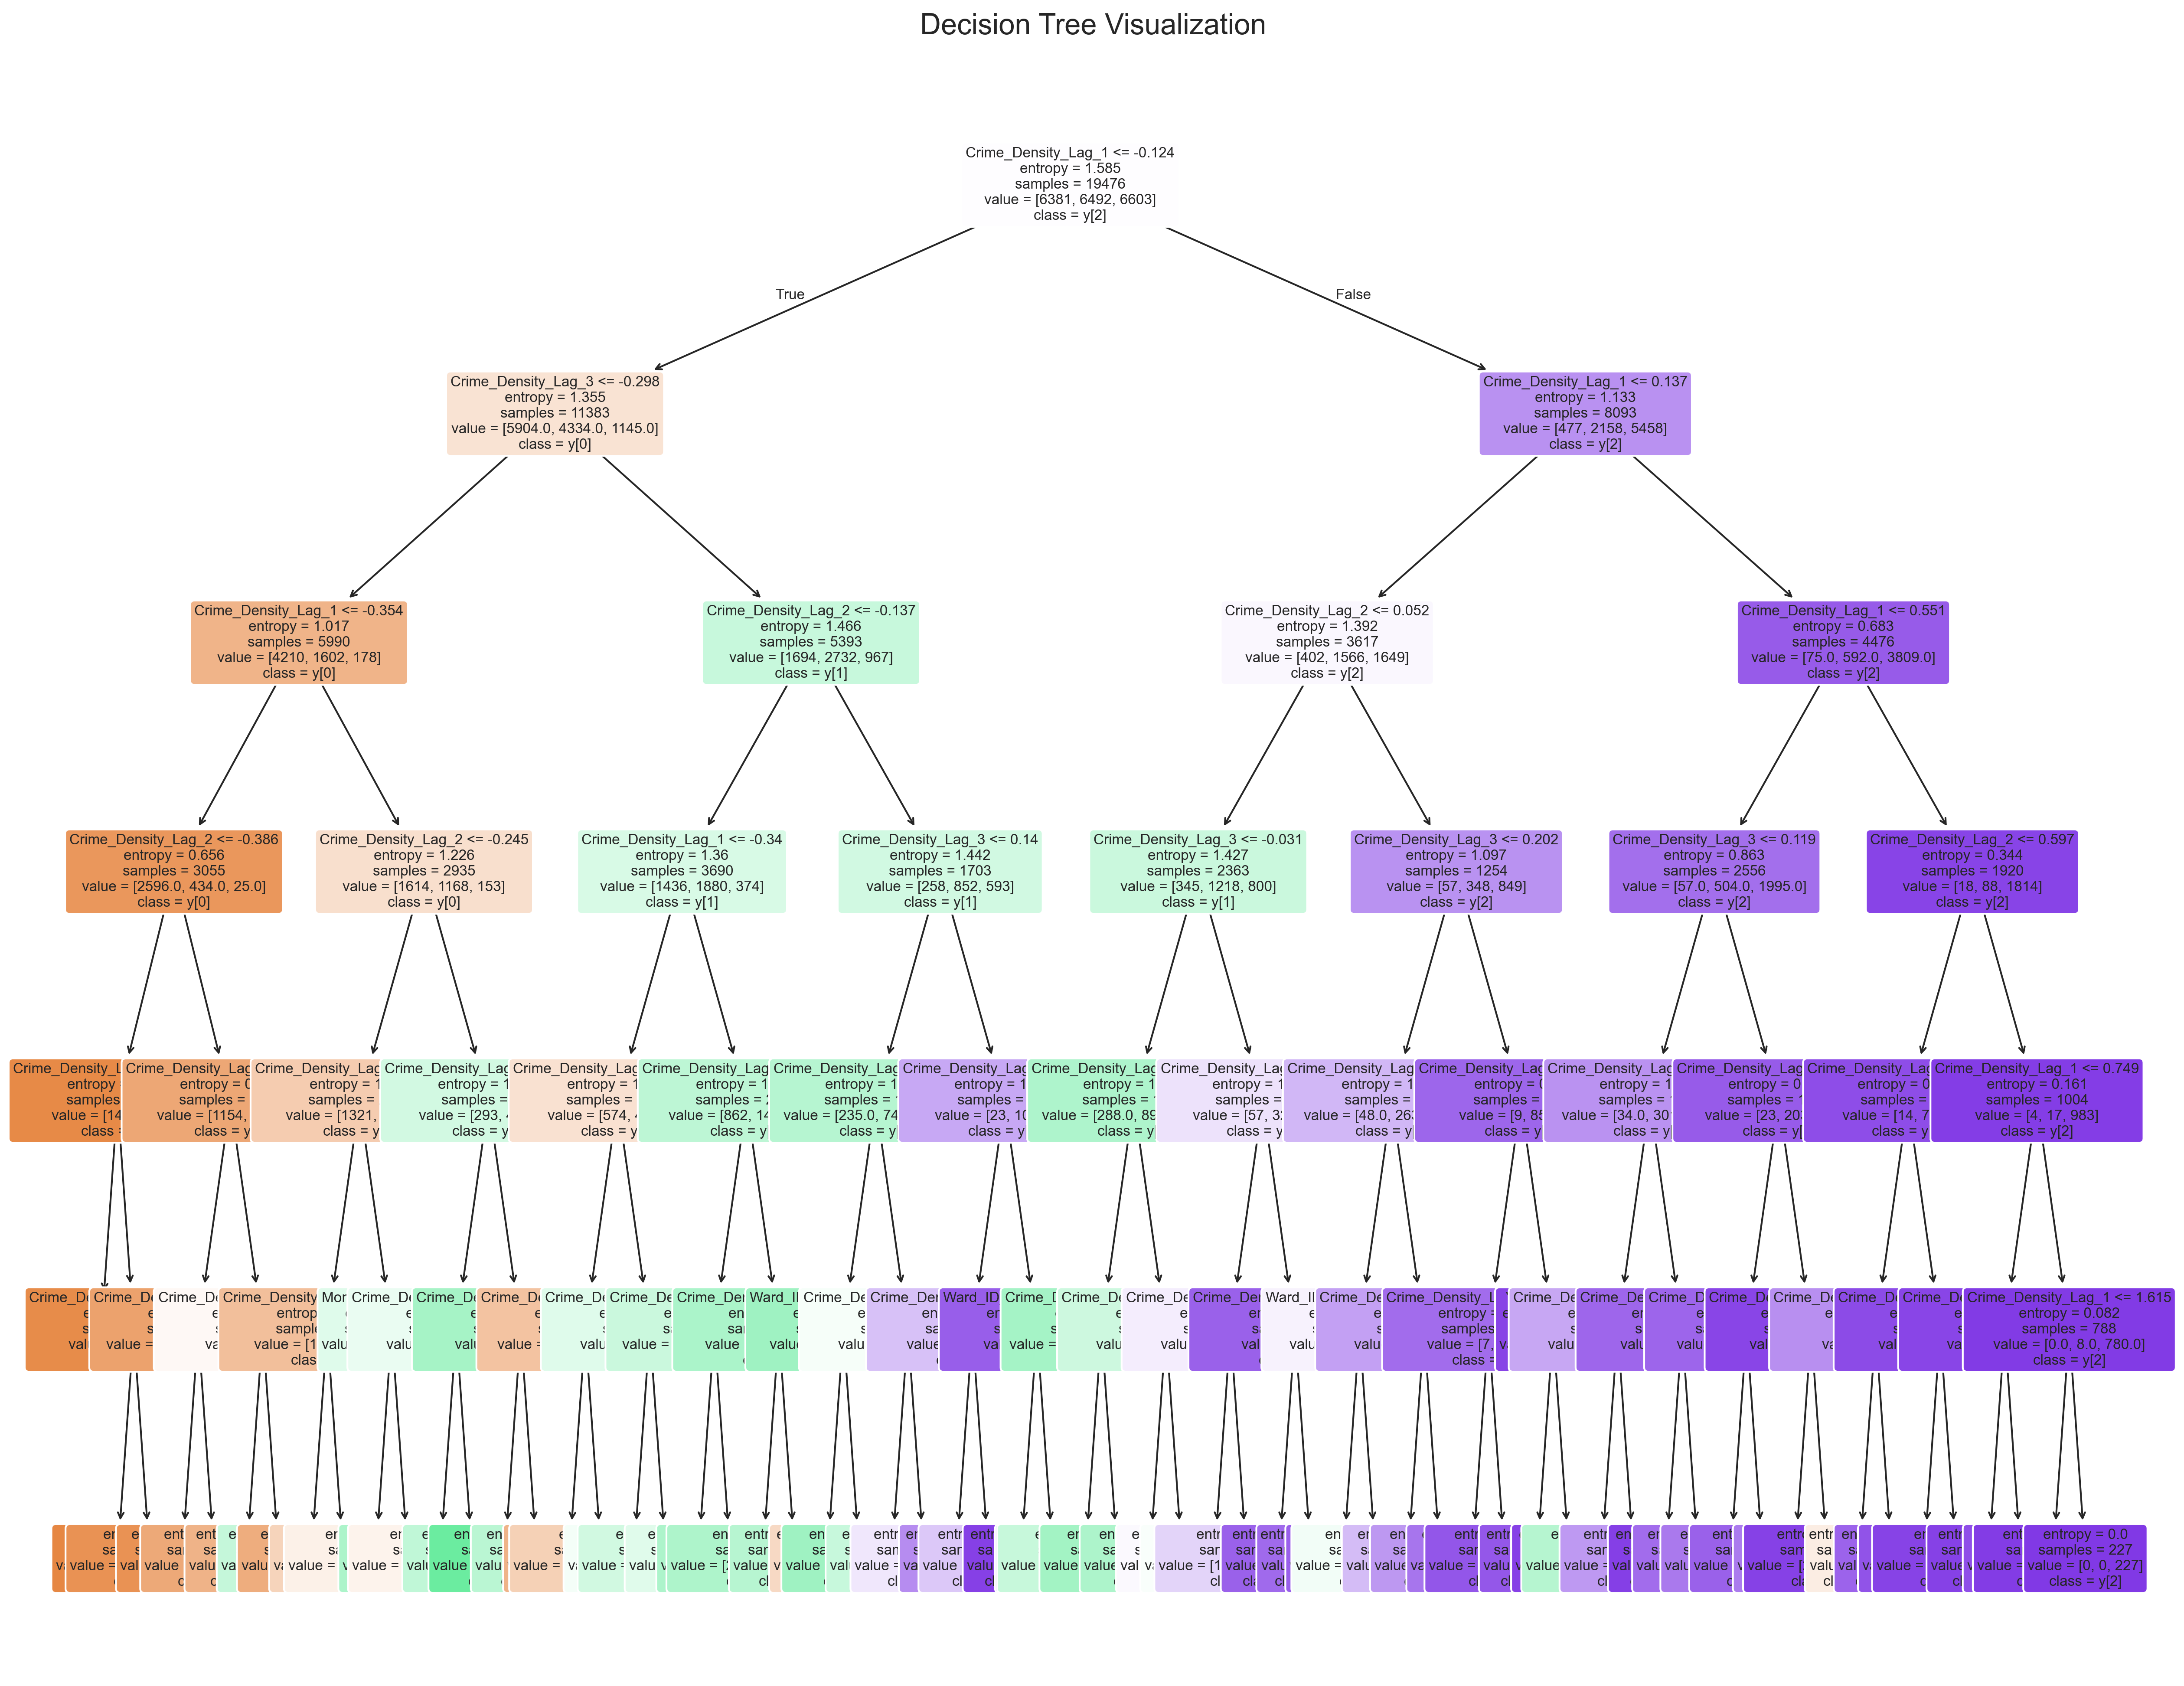

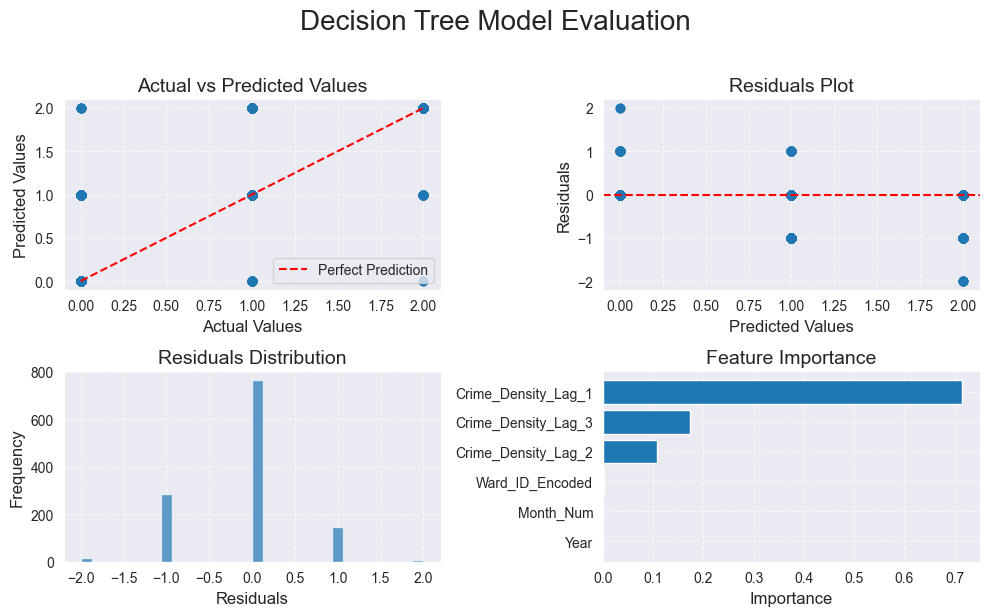

In [7]:
# For the decision tree visualization
plt.figure(figsize=(20,16), dpi=300)
plot_tree(
    dt,  # Using your best_model from XGBoost
    feature_names=X_train.columns,
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization", fontsize=16, pad=20)
plt.show()

# For regression evaluation, instead of ROC curve, let's create a more appropriate visualization
# Create a figure with multiple subplots for comprehensive evaluation
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Decision Tree Model Evaluation', fontsize=20, y=1.02)

# 1. Actual vs Predicted Scatter Plot
ax1.scatter(y_test, y_pred, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
ax1.set_xlabel('Actual Values', fontsize=12)
ax1.set_ylabel('Predicted Values', fontsize=12)
ax1.set_title('Actual vs Predicted Values', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 2. Residuals Plot
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residuals Plot', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)

# 3. Residuals Distribution
ax3.hist(residuals, bins=30, alpha=0.7)
ax3.set_xlabel('Residuals', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Residuals Distribution', fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.7)

# 4. Feature Importance
importances = dt.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)
ax4.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
ax4.set_xlabel('Importance', fontsize=12)
ax4.set_title('Feature Importance', fontsize=14)
ax4.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\20232755\PycharmProjects\4CBLW00-20-group-27\venv\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


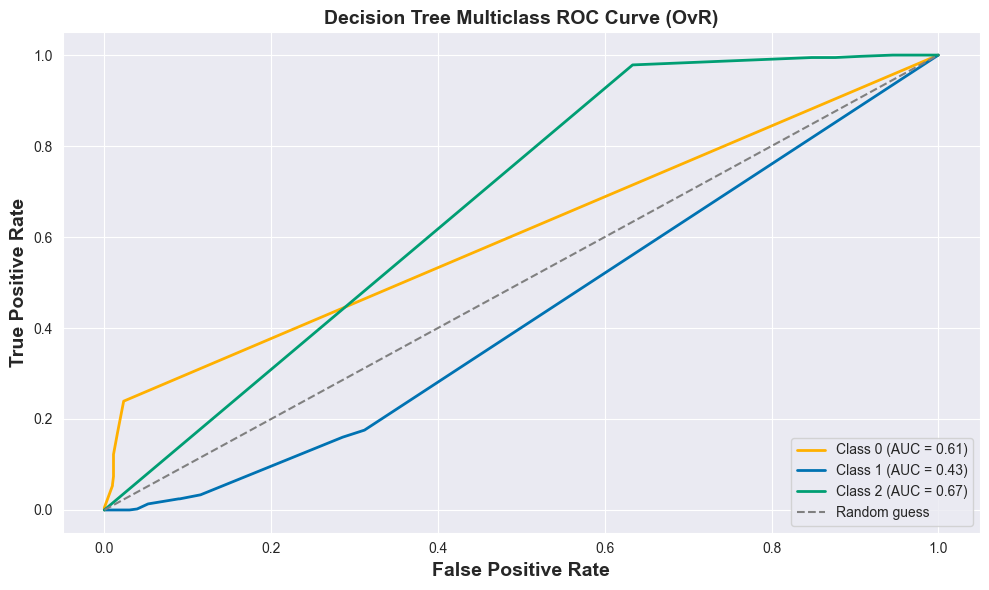

In [8]:
# Get probability predictions from your decision tree model
from sklearn.metrics import roc_curve, auc as roc_auc_score  # Rename auc to roc_auc_score

# Get probability predictions from your decision tree model
y_pred_prob = dt.predict_proba(X_test)

# Calculate ROC curve and ROC area for each class
n_classes = y_test_bin.shape[1]
roc_auc_dict = dict()
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_dict[i] = roc_auc_score(fpr[i], tpr[i])  # Using roc_auc_score instead of auc

# Plot all ROC curves
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FFB000', '#0072B2', '#009E73']  # Customize for number of classes

for i in range(n_classes):
    ax.plot(fpr[i], tpr[i], color=colors[i % len(colors)],
            lw=2, label=f"Class {i} (AUC = {roc_auc_dict[i]:.2f})")

# Diagonal (random guess)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random guess')

# Custom plot styling
ax.set_xlabel("False Positive Rate", fontsize=14, fontweight='bold')
ax.set_ylabel("True Positive Rate", fontsize=14, fontweight='bold')
ax.set_title("Decision Tree Multiclass ROC Curve (OvR)", fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()


# Cross-Validation with 5 Folds

In [9]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt, X_train, y_train, cv=5
                         
                         )
print(f"F1-Weighted Cross-Validation Scores: {scores}")

F1-Weighted Cross-Validation Scores: [0.55672485 0.65314506 0.63620026 0.65725289 0.42079589]


# Hyper-parameter Tuning
In this section, we will systematically search for the best hyper-parameter values for the decision tree model. Hyper-parameters are model settings that we do not learn from the data directly, for example `max_depth`, and tuning them can significantly improve our model’s performance and generalizability.

1. **What to consider:**
   - Specifying a range of potential values for each hyper-parameter we can optimize.
   - For the decision tree, we can vary values with `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`.
2. **Strategy:**
    - Using `GridSearchCV` to evaluate all hyper-parameter combinations.
    - Each combination is assessed via cross-validation on the training set.

---
## Visualizing the full tree to get a better overview
Before we start, we will generate a visualization of the full decision tree with all its leaves. This will help us in deciding which depth we want to use.

In [10]:
# helper function to visualize the tree
def get_dt_graph(dt_classifier):
    fig = plt.figure(figsize=(20,10), dpi=300)
    fig.savefig('Pictures/full_decision_tree_depth', dpi=300)
    _ = plot_tree(dt_classifier,
                       feature_names=X_train_scaled.columns,
                       class_names=['Survives', 'Died'],
                       filled=True)

In [11]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

## Terms meaning
**min_samples_split:**

This parameter specifies the number of samples required to split an internal node.
- **Value 2:** Can lead to very deep, overfitting trees.
- **Higher values:** Tend to produce shallower trees, reducing variance and overfitting. (If too high, might lead to underfitting)

**min_samples_leaf:**

This parameter specifies the minimum number of samples required to be at a leaf node.
- **Value 1:** Can lead to overfitting on noisy data.
- **Higher values:** Forces leaves to have more samples, smoothing out predictions and reducing variance. Can improve generalization but might lose some fine-grained patterns if set too large.

### Settings selection
1. `max_depth` (3, 5, 7, 10, 15, None)
    - Depths (3-7): More interpretable, and less prone to overfitting, but may underfit if the data is complex.
    - Depths (10–15): Can capture more complexity in the data, balance between interpretability and predictive power.
    - Depths (20 or None): May overfit, memorizing training data quirks, and hard to interpret.
2. `min_samples_split` (2,5,10,20, 50)
   - Lower values (like 2) allow splits with very few samples, which might lead to overfitting.
   - Higher values produce shallower trees and reduce variance, though too high might prevent useful splits.
3. `min_samples_leaf` (1, 2, 5, 10, 20)
   - Lower values may result in leaves with too few samples, leading to overfitting.
   - Higher values enforce a minimum number of samples per leaf, which can smooth predictions and improve generalization.
4. `criterion`
   - `gini`: Uses the Gini impurity index to measure the quality of splits.
   - `entropy`: Uses information gain (based on entropy) to determine the best splits.

In [12]:
params = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "criterion": ['gini', 'entropy']
}

In [13]:
grid_search = GridSearchCV(
    estimator=dt_default,
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

In [14]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20, 50]},
             scoring='accuracy')

In [15]:
print("Best Accuracy score:", grid_search.best_score_)
print("Best parameters found:", grid_search.best_params_)

Best Accuracy score: 0.6242535973830504
Best parameters found: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Results

#### Best parameters (based on accuracy)
The best parameters for accuracy are:
- `max_depth`: 3
- `min_samples_leaf`: 1
- `min_samples split`: 2
- `criterion`: entropy
